Data science project by John Kent, including model training and deployment of a predictor of house prices in London.

In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor


In [27]:
df = pd.read_csv('kaggle_london_house_price_data.csv')

In [28]:
df.head()

,fullAddress,postcode,country,outcode,latitude,longitude,bathrooms,bedrooms,floorAreaSqM,livingRooms,...,saleEstimate_upperPrice,saleEstimate_confidenceLevel,saleEstimate_ingestedAt,saleEstimate_valueChange.numericChange,saleEstimate_valueChange.percentageChange,saleEstimate_valueChange.saleDate,history_date,history_price,history_percentageChange,history_numericChange
0,"Flat 9, 35 Furnival Street, London, EC4A 1JQ",EC4A 1JQ,England,EC4A,51.517282,-0.110314,1.0,1.0,45.0,1.0,...,630000.0,HIGH,2024-10-07T13:26:59.894Z,244000.0,68.539326,2010-03-30,1995-01-02,830000,NaN,NaN
1,"Flat 6, 35 Furnival Street, London, EC4A 1JQ",EC4A 1JQ,England,EC4A,51.517282,-0.110314,NaN,NaN,NaN,NaN,...,660000.0,MEDIUM,2024-10-07T13:26:59.894Z,425000.0,242.857143,2000-05-26,1995-01-02,830000,NaN,NaN
2,"Flat 35, Octavia House, Medway Street, London,...",SW1P 2TA,England,SW1P,51.495505,-0.132379,2.0,2.0,71.0,1.0,...,834000.0,MEDIUM,2025-01-10T11:04:57.114Z,49000.0,6.901408,2019-09-04,1995-01-03,249950,NaN,NaN
3,"24 Chester Court, Lomond Grove, London, SE5 7HS",SE5 7HS,England,SE5,51.478185,-0.092201,1.0,1.0,64.0,1.0,...,407000.0,HIGH,2024-10-07T13:26:59.894Z,28000.0,7.777778,2024-01-25,1995-01-03,32000,NaN,NaN
4,"18 Alexandra Gardens, London, N10 3RL",N10 3RL,England,N10,51.588774,-0.139599,1.0,4.0,137.0,2.0,...,1324000.0,HIGH,2024-10-07T13:26:59.894Z,81000.0,6.864407,2022-12-14,1995-01-03,133000,NaN,NaN


In [29]:
print(df.shape)

(418201, 28)


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 418201 entries, 0 to 418200
Data columns (total 28 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   fullAddress                                418201 non-null  object 
 1   postcode                                   418201 non-null  object 
 2   country                                    418201 non-null  object 
 3   outcode                                    418201 non-null  object 
 4   latitude                                   418201 non-null  float64
 5   longitude                                  418201 non-null  float64
 6   bathrooms                                  340270 non-null  float64
 7   bedrooms                                   377665 non-null  float64
 8   floorAreaSqM                               392991 non-null  float64
 9   livingRooms                                357701 non-null  float64
 10  tenure  

In [31]:
df.describe()

,latitude,longitude,bathrooms,bedrooms,floorAreaSqM,livingRooms,rentEstimate_lowerPrice,rentEstimate_currentPrice,rentEstimate_upperPrice,saleEstimate_lowerPrice,saleEstimate_currentPrice,saleEstimate_upperPrice,saleEstimate_valueChange.numericChange,saleEstimate_valueChange.percentageChange,history_price,history_percentageChange,history_numericChange
count,418201.000000,418201.000000,340270.000000,377665.000000,392991.000000,357701.000000,416460.000000,416460.000000,416460.000000,4.175610e+05,4.175610e+05,4.175610e+05,4.175610e+05,417561.000000,4.182010e+05,237982.000000,2.379820e+05
mean,51.507522,-0.101426,1.444265,2.474884,98.926543,1.282275,3299.054171,3639.487466,3980.117298,8.312692e+05,9.045188e+05,9.777633e+05,2.886077e+04,29.278605,6.395840e+05,105.877778,2.528741e+05
std,0.056171,0.086930,0.724478,1.160506,55.938911,0.574412,3168.625404,3487.801945,3808.508868,8.088434e+05,9.202917e+05,1.037913e+06,1.080893e+06,362.350731,1.327933e+06,338.849944,8.024032e+05
min,51.385708,-0.347055,1.000000,1.000000,10.000000,1.000000,300.000000,350.000000,400.000000,8.100000e+04,8.900000e+04,9.300000e+04,-1.053770e+08,-99.763196,1.000000e+04,-99.890110,-7.390000e+07
25%,51.464315,-0.155996,1.000000,2.000000,63.000000,1.000000,1800.000000,1950.000000,2100.000000,4.160000e+05,4.460000e+05,4.750000e+05,1.100000e+04,2.105263,2.280000e+05,17.833333,4.849500e+04
50%,51.501581,-0.108482,1.000000,2.000000,84.000000,1.000000,2350.000000,2600.000000,2850.000000,5.810000e+05,6.220000e+05,6.630000e+05,3.500000e+04,6.260870,4.000000e+05,52.857143,1.300000e+05
75%,51.548515,-0.043582,2.000000,3.000000,116.000000,1.000000,3550.000000,3950.000000,4300.000000,9.130000e+05,9.840000e+05,1.054000e+06,8.600000e+04,13.554987,6.650000e+05,114.285714,2.870000e+05
max,51.665823,0.139249,9.000000,9.000000,500.000000,9.000000,111500.000000,121200.000000,130900.000000,2.337600e+07,2.922000e+07,3.506400e+07,2.268100e+07,48860.000000,1.058000e+08,48800.770000,6.382000e+07


In [32]:
print(df.isnull().sum())

fullAddress                                       0
postcode                                          0
country                                           0
outcode                                           0
latitude                                          0
longitude                                         0
bathrooms                                     77931
bedrooms                                      40536
floorAreaSqM                                  25210
livingRooms                                   60500
tenure                                        11512
propertyType                                   1136
currentEnergyRating                           84526
rentEstimate_lowerPrice                        1741
rentEstimate_currentPrice                      1741
rentEstimate_upperPrice                        1741
saleEstimate_lowerPrice                         640
saleEstimate_currentPrice                       640
saleEstimate_upperPrice                         640
saleEstimate

In [33]:
df = df.dropna(subset=['bedrooms', 'floorAreaSqM','bathrooms', 'livingRooms','saleEstimate_currentPrice', 'livingRooms'])

In [34]:
print(df.isnull().sum())

fullAddress                                       0
postcode                                          0
country                                           0
outcode                                           0
latitude                                          0
longitude                                         0
bathrooms                                         0
bedrooms                                          0
floorAreaSqM                                      0
livingRooms                                       0
tenure                                         1702
propertyType                                      0
currentEnergyRating                           51266
rentEstimate_lowerPrice                          16
rentEstimate_currentPrice                        16
rentEstimate_upperPrice                          16
saleEstimate_lowerPrice                           0
saleEstimate_currentPrice                         0
saleEstimate_upperPrice                           0
saleEstimate

In [35]:
print(df.shape)

(318578, 28)


In [36]:
unique_B = df['propertyType'].unique()
print(unique_B)

['Purpose Built Flat' 'Flat/Maisonette' 'End Terrace House'
 'Mid Terrace House' 'Terrace Property' 'Semi-Detached House'
 'Converted Flat' 'Detached House' 'Bungalow Property' 'Terraced'
 'Detached Bungalow' 'Mid Terrace Property' 'Mid Terrace Bungalow'
 'Semi-Detached Bungalow' 'End Terrace Property' 'Terraced Bungalow'
 'Semi-Detached Property' 'Detached Property' 'End Terrace Bungalow']


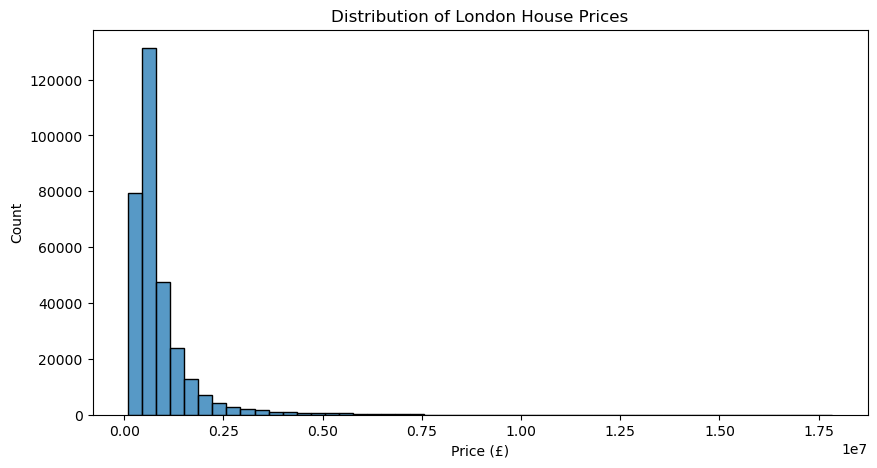

In [37]:
plt.figure(figsize=(10, 5))
sns.histplot(df['saleEstimate_currentPrice'], bins=50, kde=False)
plt.title('Distribution of London House Prices')
plt.xlabel('Price (£)')
plt.ylabel('Count')
plt.show()

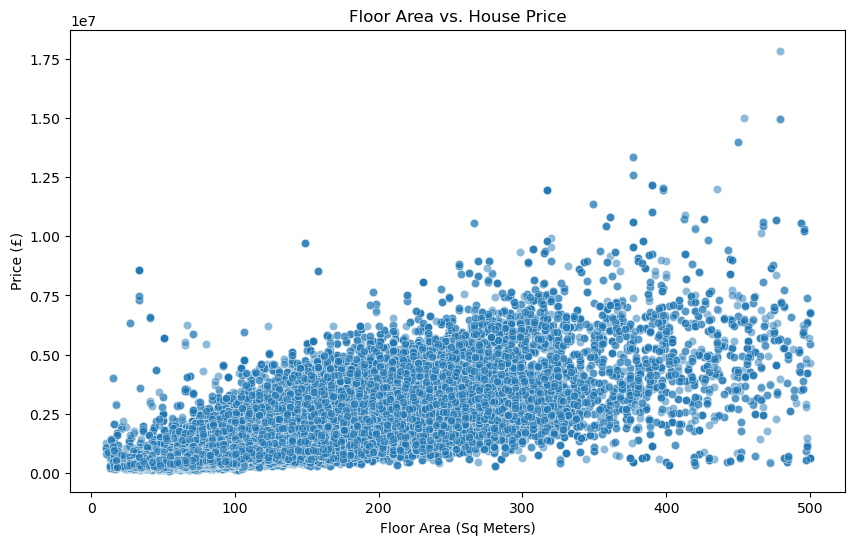

In [38]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='floorAreaSqM', y='saleEstimate_currentPrice', alpha=0.5)
plt.title('Floor Area vs. House Price')
plt.xlabel('Floor Area (Sq Meters)')
plt.ylabel('Price (£)')
plt.show()

In [39]:
top_expensive_areas = df.groupby('outcode')['saleEstimate_currentPrice'].mean().sort_values(ascending=False).head(20)
print(top_expensive_areas)

outcode
SW1X    3.685190e+06
SW1W    2.725883e+06
W8      2.670850e+06
W1K     2.608897e+06
SW7     2.513461e+06
W1S     2.372949e+06
W1J     2.370038e+06
SW1A    2.298626e+06
SW3     2.280973e+06
W1B     2.154345e+06
W11     1.920769e+06
W1G     1.919240e+06
NW8     1.855893e+06
SW10    1.848482e+06
WC2R    1.841605e+06
SW1Y    1.739645e+06
W1H     1.696844e+06
SW1E    1.666910e+06
W1U     1.627606e+06
SW13    1.625872e+06
Name: saleEstimate_currentPrice, dtype: float64


Remove any data entry that is not within the co-ordinates of London.

In [40]:
london_box = (df['latitude'].between(51.25, 51.70)) & (df['longitude'].between(-0.55, 0.30))
df = df[london_box]

Remove outliers due to potential data entry errors

In [41]:
lower_limit = df['saleEstimate_currentPrice'].quantile(0.01)
upper_limit = df['saleEstimate_currentPrice'].quantile(0.99)

df_clean = df[(df['saleEstimate_currentPrice'] >= lower_limit) & (df['saleEstimate_currentPrice'] <= upper_limit)]

print(f"Removed {len(df) - len(df_clean)} price outliers.")

Removed 6307 price outliers.


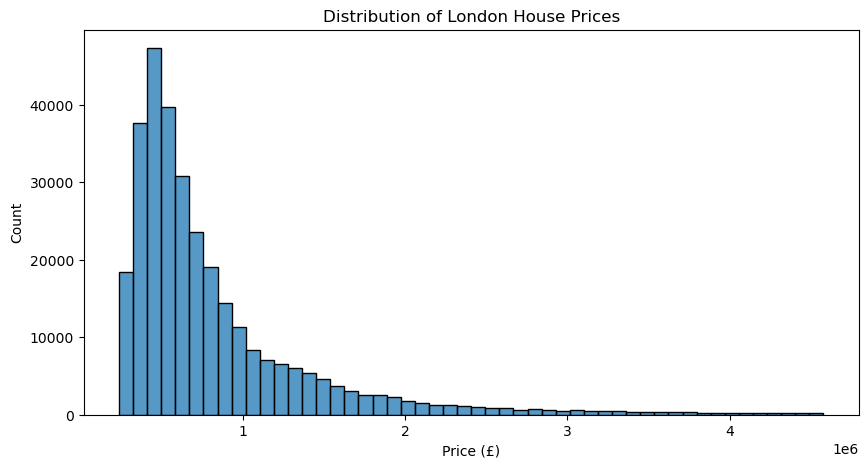

In [42]:
plt.figure(figsize=(10, 5))
sns.histplot(df_clean['saleEstimate_currentPrice'], bins=50, kde=False)
plt.title('Distribution of London House Prices')
plt.xlabel('Price (£)')
plt.ylabel('Count')
plt.show()

The data is still right skewed, so we perform a log transformation on the price estimates.

C:\Users\kentj\AppData\Local\Temp\ipykernel_57108\2919776795.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['log_price'] = np.log1p(df_clean['saleEstimate_currentPrice'])


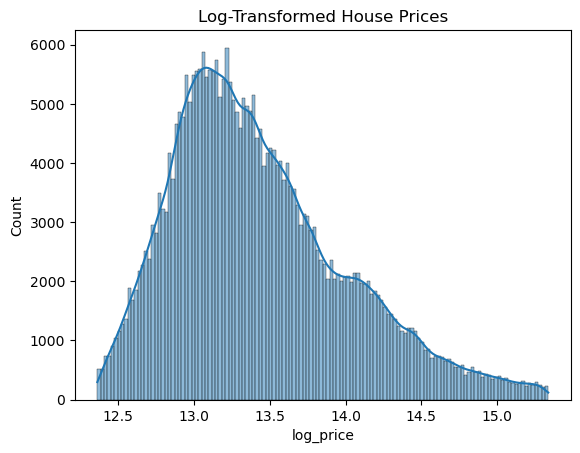

In [43]:
df_clean['log_price'] = np.log1p(df_clean['saleEstimate_currentPrice'])

sns.histplot(df_clean['log_price'], kde=True)
plt.title('Log-Transformed House Prices')
plt.show()

Now we set about creating a new column for the distance to the centre of London

First we use the Haversine formula for calculating distances given co-ordinates

In [44]:
def haversine_distance(lat1, lon1, lat2, lon2):
    lat1, lon1, lat2, lon2 = map(np.radians, [lat1, lon1, lat2, lon2])
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    
    km = 6371
    return c * km

CENTRE_LAT = 51.5074
CENTRE_LON = -0.1278

df_clean['distance_to_centre'] = haversine_distance(df['latitude'], df['longitude'], CENTRE_LAT, CENTRE_LON)

print(df_clean[['outcode', 'distance_to_centre']].head())

  outcode  distance_to_centre
0    EC4A            1.634534
2    SW1P            1.360143
3     SE5            4.077599
4     N10            9.085086
5     SE3           10.400731


C:\Users\kentj\AppData\Local\Temp\ipykernel_57108\1425915829.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['distance_to_centre'] = haversine_distance(df['latitude'], df['longitude'], CENTRE_LAT, CENTRE_LON)


In [45]:
postcode_stats = df.groupby('outcode').agg(
    avg_price=('saleEstimate_currentPrice', 'mean'),
    median_price=('saleEstimate_currentPrice', 'median'),
    property_count=('saleEstimate_currentPrice', 'count')
).reset_index()

print(postcode_stats.sort_values(by='median_price', ascending=False).head(10))

    outcode     avg_price  median_price  property_count
117    SW1X  3.685190e+06     3238000.0            1414
140     W1K  2.608897e+06     2207000.0            1402
141     W1S  2.372949e+06     2027000.0             197
151      W8  2.670850e+06     2017000.0            1190
125     SW7  2.513461e+06     1990000.0            1408
116    SW1W  2.725883e+06     1909000.0            1576
166    WC2R  1.841605e+06     1744000.0             238
139     W1J  2.370038e+06     1725000.0            1068
133     W1B  2.154345e+06     1677000.0             359
137     W1G  1.919240e+06     1619000.0            1261


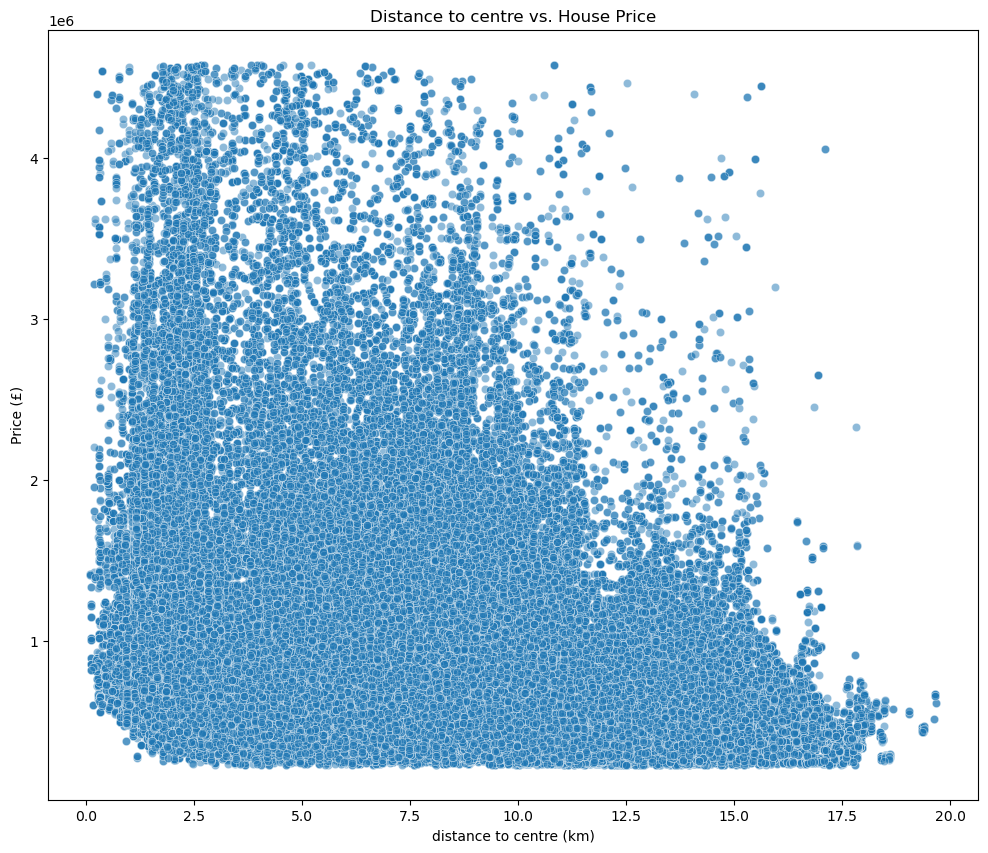

In [46]:
plt.figure(figsize=(12, 10))
sns.scatterplot(data=df_clean, x='distance_to_centre', y='saleEstimate_currentPrice', alpha=0.5)
plt.title('Distance to centre vs. House Price')
plt.xlabel('distance to centre (km)')
plt.ylabel('Price (£)')
plt.show()

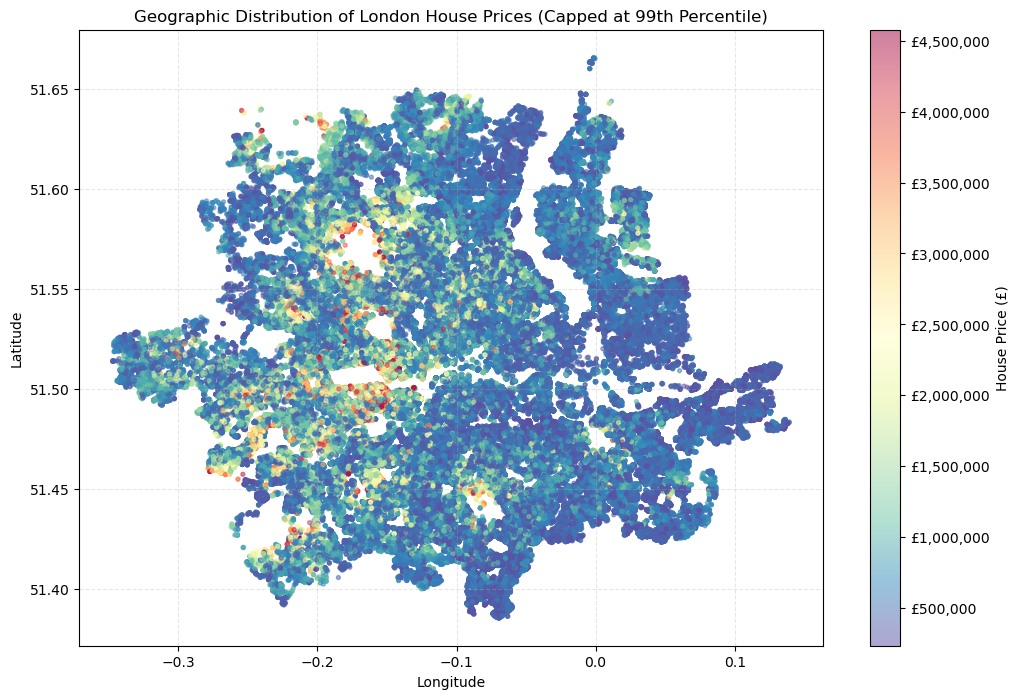

In [47]:
plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    df_clean['longitude'], 
    df_clean['latitude'], 
    c=df_clean['saleEstimate_currentPrice'], 
    cmap='Spectral_r', 
    alpha=0.5, 
    s=8
)

cbar = plt.colorbar(scatter, label='House Price (£)')
cbar.ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"£{int(x):,}"))

plt.title('Geographic Distribution of London House Prices (Capped at 99th Percentile)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.grid(True, linestyle='--', alpha=0.3)

plt.show()

In [48]:
postcode_stats = df.groupby('outcode').agg(
    avg_price=('saleEstimate_currentPrice', 'mean'),
    median_price=('saleEstimate_currentPrice', 'median'),
    property_count=('saleEstimate_currentPrice', 'count')
).reset_index()

# Sort by the most expensive areas
print(postcode_stats.sort_values(by='median_price', ascending=False).head(10))

    outcode     avg_price  median_price  property_count
117    SW1X  3.685190e+06     3238000.0            1414
140     W1K  2.608897e+06     2207000.0            1402
141     W1S  2.372949e+06     2027000.0             197
151      W8  2.670850e+06     2017000.0            1190
125     SW7  2.513461e+06     1990000.0            1408
116    SW1W  2.725883e+06     1909000.0            1576
166    WC2R  1.841605e+06     1744000.0             238
139     W1J  2.370038e+06     1725000.0            1068
133     W1B  2.154345e+06     1677000.0             359
137     W1G  1.919240e+06     1619000.0            1261


OHE to convert categorical data to numerical data

In [49]:
df_encoded = pd.get_dummies(df_clean, columns=['propertyType'], drop_first=True, dtype=int)

In [50]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 312271 entries, 0 to 418200
Data columns (total 47 columns):
 #   Column                                     Non-Null Count   Dtype  
---  ------                                     --------------   -----  
 0   fullAddress                                312271 non-null  object 
 1   postcode                                   312271 non-null  object 
 2   country                                    312271 non-null  object 
 3   outcode                                    312271 non-null  object 
 4   latitude                                   312271 non-null  float64
 5   longitude                                  312271 non-null  float64
 6   bathrooms                                  312271 non-null  float64
 7   bedrooms                                   312271 non-null  float64
 8   floorAreaSqM                               312271 non-null  float64
 9   livingRooms                                312271 non-null  float64
 10  tenure       

Target encoding to convert categorical data into numerical. We use target encoding because there are many unique outcodes

In [51]:
outcode_means = df_encoded.groupby('outcode')['saleEstimate_currentPrice'].mean()

df_encoded['outcode_encoded'] = df_encoded['outcode'].map(outcode_means)

df_encoded = df_encoded.drop(columns=['outcode'])

print(df_encoded[['outcode_encoded', 'saleEstimate_currentPrice']].head())

   outcode_encoded  saleEstimate_currentPrice
0     6.761148e+05                   600000.0
2     1.096149e+06                   759000.0
3     6.570587e+05                   388000.0
4     1.052224e+06                  1261000.0
5     7.229041e+05                   944000.0


In [52]:
print(df_encoded.columns)

Index(['fullAddress', 'postcode', 'country', 'latitude', 'longitude',
       'bathrooms', 'bedrooms', 'floorAreaSqM', 'livingRooms', 'tenure',
       'currentEnergyRating', 'rentEstimate_lowerPrice',
       'rentEstimate_currentPrice', 'rentEstimate_upperPrice',
       'saleEstimate_lowerPrice', 'saleEstimate_currentPrice',
       'saleEstimate_upperPrice', 'saleEstimate_confidenceLevel',
       'saleEstimate_ingestedAt', 'saleEstimate_valueChange.numericChange',
       'saleEstimate_valueChange.percentageChange',
       'saleEstimate_valueChange.saleDate', 'history_date', 'history_price',
       'history_percentageChange', 'history_numericChange', 'log_price',
       'distance_to_centre', 'propertyType_Converted Flat',
       'propertyType_Detached Bungalow', 'propertyType_Detached House',
       'propertyType_Detached Property', 'propertyType_End Terrace Bungalow',
       'propertyType_End Terrace House', 'propertyType_End Terrace Property',
       'propertyType_Flat/Maisonette', 'pr

In [53]:
columns_to_drop = ['fullAddress', 'postcode', 'country', 'latitude', 'longitude','tenure',
       'currentEnergyRating', 'rentEstimate_lowerPrice',
       'rentEstimate_currentPrice', 'rentEstimate_upperPrice',
       'saleEstimate_lowerPrice','saleEstimate_upperPrice', 'saleEstimate_confidenceLevel',
       'saleEstimate_ingestedAt', 'saleEstimate_valueChange.numericChange',
       'saleEstimate_valueChange.percentageChange',
       'saleEstimate_valueChange.saleDate', 'history_date', 'history_price',
       'history_percentageChange', 'history_numericChange']
df_final = df_encoded.drop(columns=[col for col in columns_to_drop if col in df_encoded.columns])

print(df_final.dtypes)

bathrooms                              float64
bedrooms                               float64
floorAreaSqM                           float64
livingRooms                            float64
saleEstimate_currentPrice              float64
log_price                              float64
distance_to_centre                     float64
propertyType_Converted Flat              int64
propertyType_Detached Bungalow           int64
propertyType_Detached House              int64
propertyType_Detached Property           int64
propertyType_End Terrace Bungalow        int64
propertyType_End Terrace House           int64
propertyType_End Terrace Property        int64
propertyType_Flat/Maisonette             int64
propertyType_Mid Terrace Bungalow        int64
propertyType_Mid Terrace House           int64
propertyType_Mid Terrace Property        int64
propertyType_Purpose Built Flat          int64
propertyType_Semi-Detached Bungalow      int64
propertyType_Semi-Detached House         int64
propertyType_

In [54]:
y = df_final['saleEstimate_currentPrice']

X = df_final.drop(columns=['saleEstimate_currentPrice','log_price'])

In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 249816
Testing samples: 62455


In [56]:
model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [57]:
predictions = model.predict(X_test)

mae = mean_absolute_error(y_test, predictions)
r2 = r2_score(y_test, predictions)

print(f"Mean Absolute Error: £{mae:,.2f}")
print(f"R² Score: {r2:.4f}")

Mean Absolute Error: £187,076.45
R² Score: 0.7797


In [58]:
joblib.dump(model, 'london_model.pkl')

['london_model.pkl']

The original predicted price to decrease with an increase number of rooms, this could be because of colinearity between sq foot and number of rooms. Linear regression is not sufficient, we will try a random forest model

In [59]:
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,10
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [60]:
rf_predictions = rf_model.predict(X_test)

# 4. Calculate performance metrics
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_r2 = r2_score(y_test, rf_predictions)

print(f"Random Forest Mean Absolute Error: £{rf_mae:,.2f}")
print(f"Random Forest R² Score: {rf_r2:.4f}")

Random Forest Mean Absolute Error: £122,663.05
Random Forest R² Score: 0.9007


In [61]:
joblib.dump(rf_model, 'london_model.pkl')

['london_model.pkl']

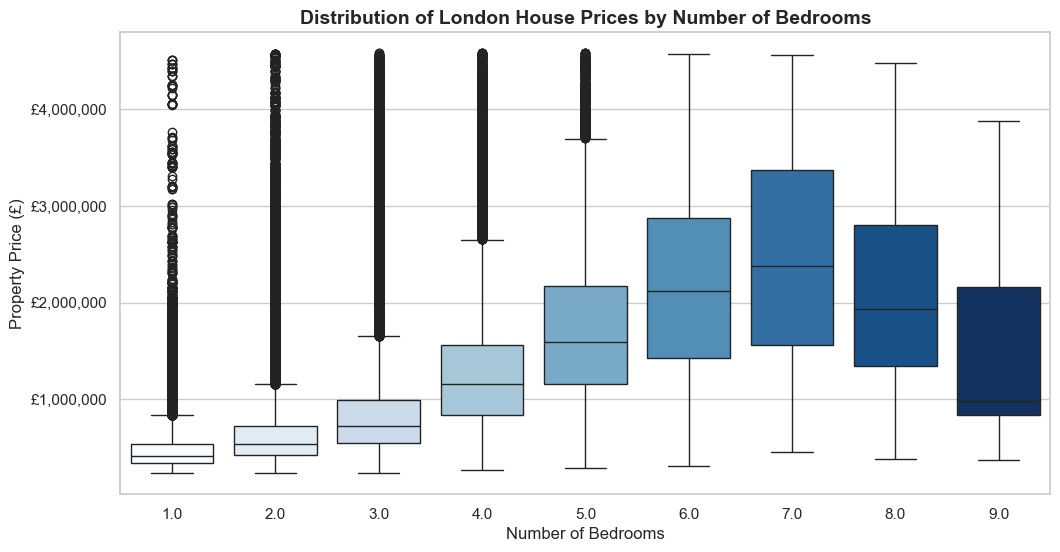

In [63]:
plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

sns.boxplot(
    data=df_clean, 
    x='bedrooms', 
    y='saleEstimate_currentPrice', 
    palette='Blues',
    hue='bedrooms',      # Adding hue avoids a modern seaborn warning
    legend=False
)

plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f"£{int(x):,}"))

plt.title('Distribution of London House Prices by Number of Bedrooms', fontsize=14, fontweight='bold')
plt.xlabel('Number of Bedrooms', fontsize=12)
plt.ylabel('Property Price (£)', fontsize=12)

plt.show()